## Implementacja generatorów typu Counter-Based

### Philox

Philox to generator typu counter-based, który wykorzystuje głównie operacje mnożenia i mieszania bitów.

Główne kroki działania:

Zaczyna od:
- licznika (counter, np. 4×32-bit)
- klucza (key, pochodzącego z seeda)


Każda runda wykonuje:
- mnożenie 32-bitowe 
- XOR (mieszanie z innymi elementami i kluczem)
- permute 

Po każdej rundzie klucz jest modyfikowany (key schedule, dodanie stałych)
Po 10 rundach otrzymujemy blok pseudolosowych liczb. Na samym końcu inkrementowany jest licznik.

In [1]:
from ipow.generators import Philox
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

{
  "generator": "philox4x32-10",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.05657888442105e+18,
    "variance": 2.8353025719156887e+37,
    "std": 5.324755930477648e+18,
    "min": 1323502219810087.0,
    "max": 1.8446718500202858e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.49755655698564877,
    "variance": 0.08466346006015128,
    "std": 0.29096986108556205,
    "min": 4.744155738722888e-05,
    "max": 0.9998772732063634
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5072,
    "ones": 4928,
    "p_zero": 0.5072,
    "p_one": 0.4928
  },
  "serial_pairs": {
    "00": 2602,
    "01": 2470,
    "10": 2470,
    "11": 2457
  },
  "tests": {
    "monobit": {
      "statistic": 1.44,
      "p_value": 0.1498673990686541,
      "pass": true
    },
    "runs": {
      "statistic": 4941.0,
      "p_value": 0.24625062987400823,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 220.35199999999998,
      "p_value": 0.942

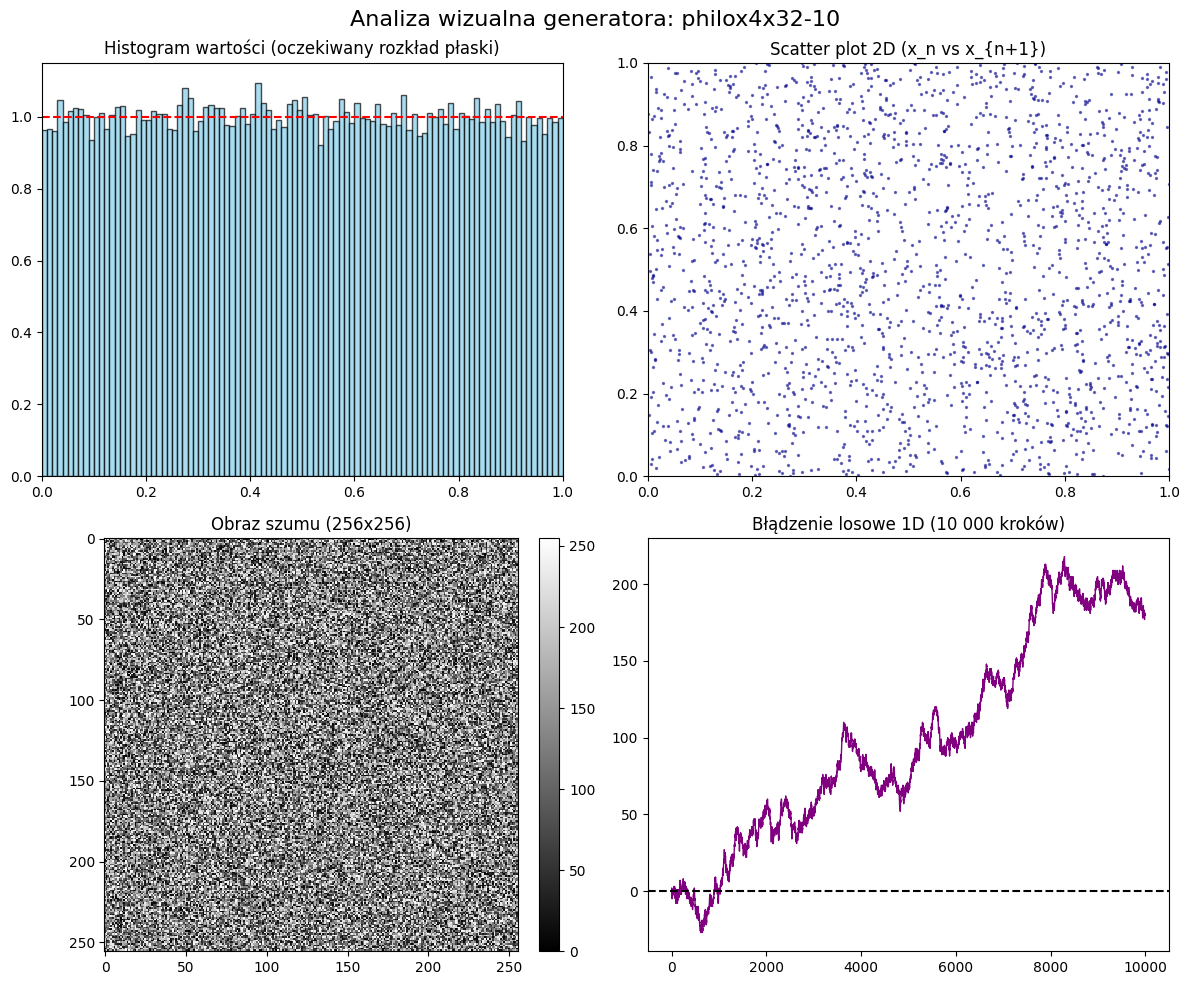

In [2]:
generator = Philox(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

### Threefry

Threefry to również generator counter-based, ale oparty o schemat ARX (Add-Rotate-XOR), inspirowany szyframi blokowymi.

Startuje od:
- licznika (counter, np. 2×64-bit)
- klucza (key)

Dodaje klucz do stan (key injection).

Każda runda wykonuje:
- dodawanie
- rotację bitową 
- XOR

Co kilka rund (np. co 4) ponownie do stanu dodawana jest wartość klucza. Po 20 rundach otrzymujemy blok pseudolosowych liczb.
Na końcu inkrementowany jest licznik.

In [1]:
from ipow.generators import Threefry
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

{
  "generator": "threefry2x64-20",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.164408178472704e+18,
    "variance": 2.852199877225109e+37,
    "std": 5.340599102371483e+18,
    "min": 2712336025849676.0,
    "max": 1.8434931974058035e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.4969597318639274,
    "variance": 0.08273101580318327,
    "std": 0.28762999809335477,
    "min": 0.00011962896596440231,
    "max": 0.9997802760889081
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4975,
    "ones": 5025,
    "p_zero": 0.4975,
    "p_one": 0.5025
  },
  "serial_pairs": {
    "00": 2471,
    "01": 2503,
    "10": 2504,
    "11": 2521
  },
  "tests": {
    "monobit": {
      "statistic": 0.5,
      "p_value": 0.6170750774519739,
      "pass": true
    },
    "runs": {
      "statistic": 5008.0,
      "p_value": 0.8709089293063799,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 247.7952,
      "p_value": 0.6150451379626

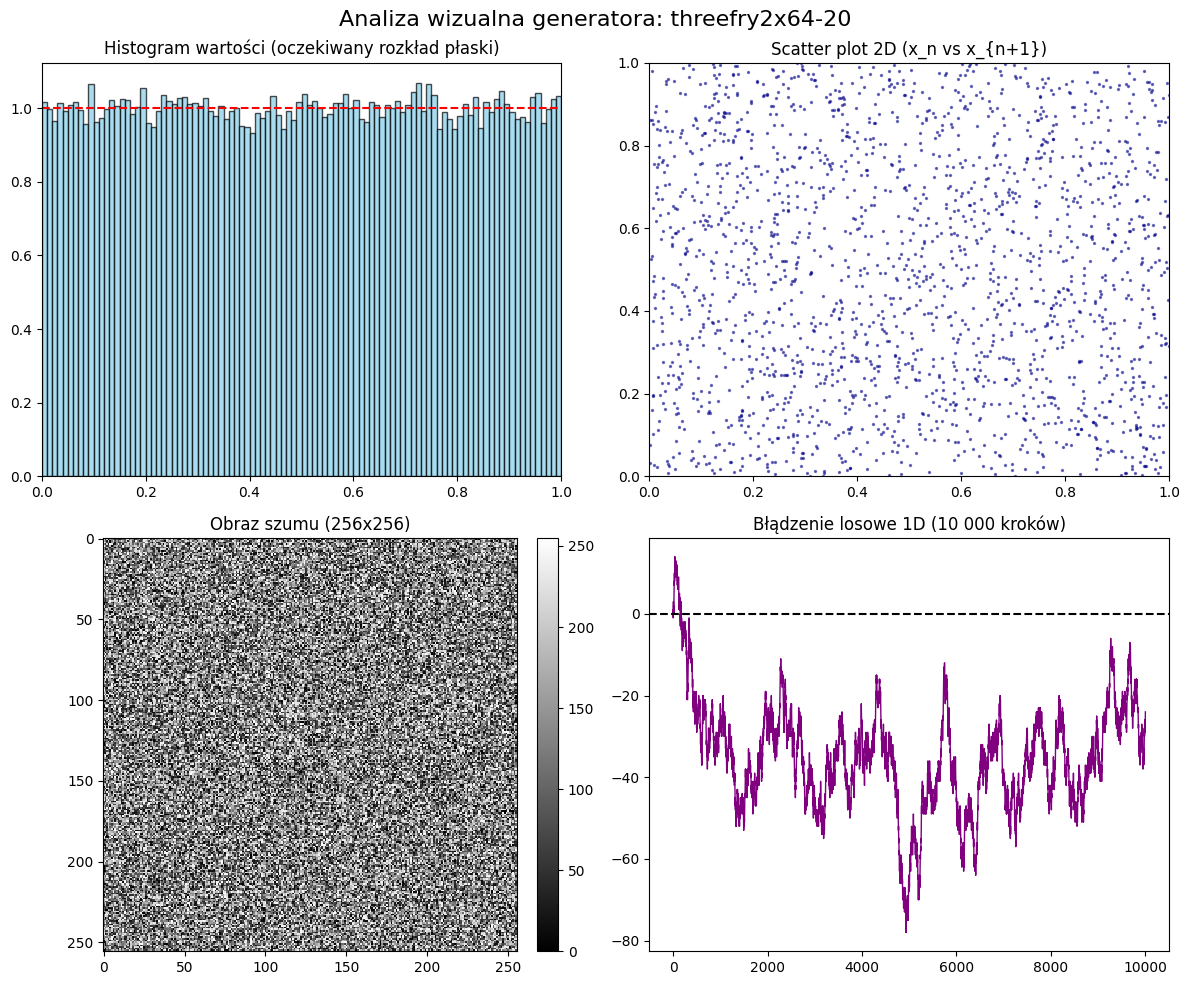

In [2]:
generator = Threefry()
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## Implementacja generatora MRG32k3a

MRG32k3a to generator pseudolosowy typu *combined multiple recursive generator*, który łączy dwa liniowe generatory działające na modulo dużych liczb pierwszych.

### Jak działa

- Utrzymuje dwa stany:
  - `s1` (mod m₁)
  - `s2` (mod m₂)

- W każdym kroku:
  - oblicza nowe wartości na podstawie liniowej kombinacji poprzednich (rekurencja)
  - operacje: mnożenie, dodawanie, modulo

- Łączy wyniki:
  - `(p1 - p2) mod m₁`

### Generowanie liczb

- liczby całkowite: bezpośrednio z wyniku
- liczby zmiennoprzecinkowe: `x / m₁` → zakres `[0, 1)`
- 64-bit: łączenie dwóch kolejnych wartości



In [1]:
from ipow.generators import MRG32k3a
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

{
  "generator": "mrg32k3a",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.218867404355676e+18,
    "variance": 2.8918925172363176e+37,
    "std": 5.377631929796161e+18,
    "min": 1544462098337483.0,
    "max": 1.8446161852489886e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5050191521740526,
    "variance": 0.08609984053320587,
    "std": 0.2934277432916081,
    "min": 8.083740642643951e-05,
    "max": 0.9996523679996246
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5019,
    "ones": 4981,
    "p_zero": 0.5019,
    "p_one": 0.4981
  },
  "serial_pairs": {
    "00": 2512,
    "01": 2506,
    "10": 2506,
    "11": 2475
  },
  "tests": {
    "monobit": {
      "statistic": 0.38,
      "p_value": 0.7039454151516744,
      "pass": true
    },
    "runs": {
      "statistic": 5013.0,
      "p_value": 0.7937472184318894,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 252.91520000000003,
      "p_value": 0.5251259412

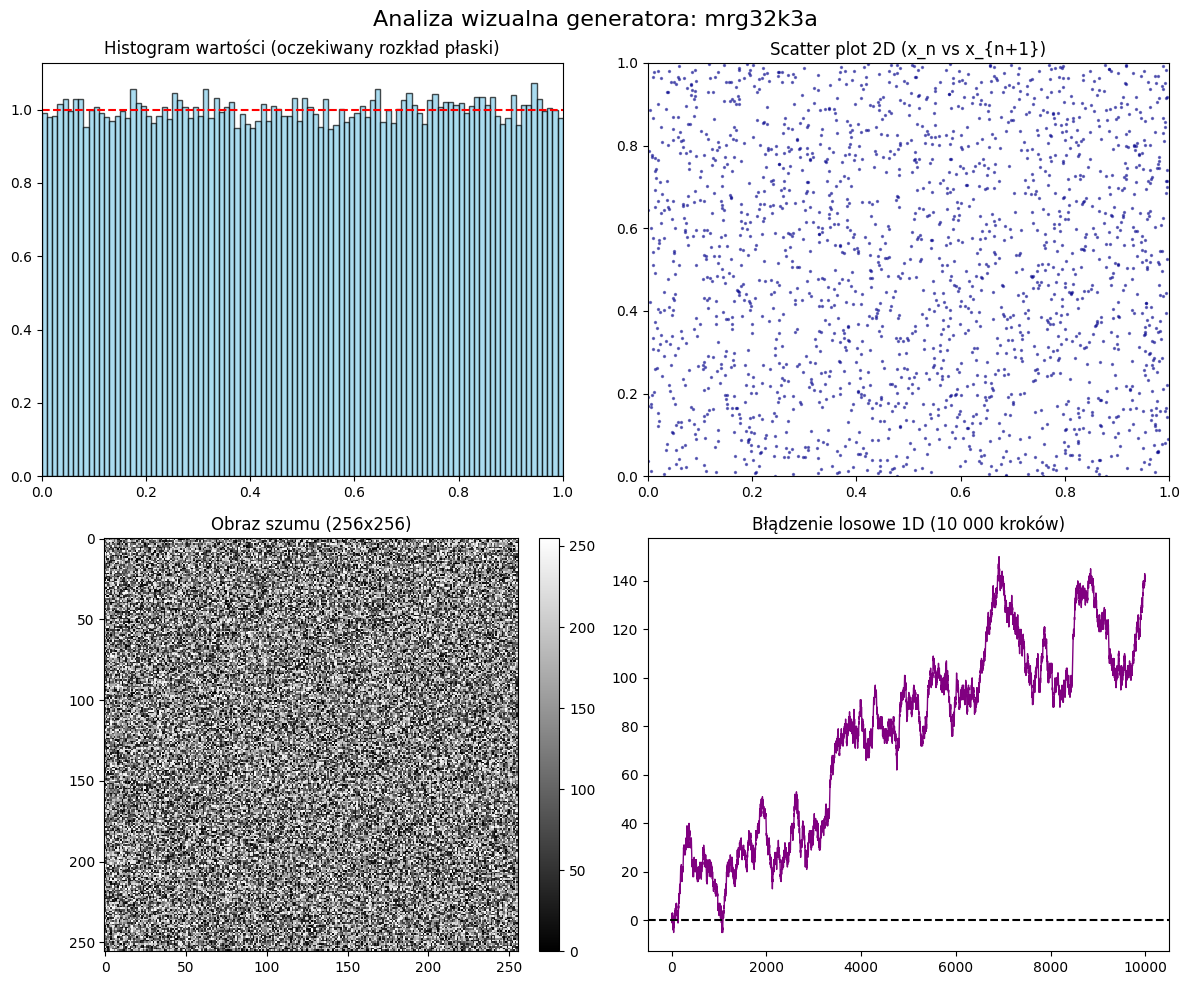

In [2]:
generator = MRG32k3a(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)